In [1]:
from stock_predictor.utils import (
    create_s3_client,
    get_latest_data_s3,
)

client = create_s3_client()

2026-03-18 09:25:12,491 | INFO | Creating S3 client...


## Loading data from MinIO

We retrieve the latest candles for a given ticker from MinIO object storage
and inspect the first rows to verify the schema and column types are correct.

In [2]:
df = get_latest_data_s3(client, "TSLA")
print(df.head())

2026-03-18 09:25:13,235 | INFO | Getting latest data from S3 bucket tsla...
2026-03-18 09:25:14,631 | INFO | Latest data file ['raw_20240229_20260317.csv'] loaded successfully.


                           v        vw       o       c       h       l    n  \
t                                                                             
2024-02-29 09:00:00  32667.0  201.5645  201.39  201.89  201.92  201.29  907   
2024-02-29 09:10:00  32028.0  201.9273  201.80  202.10  202.18  201.71  625   
2024-02-29 09:20:00  41149.0  202.4194  202.17  201.91  202.73  201.89  971   
2024-02-29 09:30:00   7683.0  202.0348  201.84  202.20  202.24  201.82  281   
2024-02-29 09:40:00  11027.0  202.2976  202.40  202.30  202.41  202.15  322   

                     average_price published_utc headline  positive  neutral  \
t                                                                              
2024-02-29 09:00:00        201.605           NaN      NaN       NaN      NaN   
2024-02-29 09:10:00        201.945           NaN      NaN       NaN      NaN   
2024-02-29 09:20:00        202.310           NaN      NaN       NaN      NaN   
2024-02-29 09:30:00        202.030           N

**Finding:** Schema and column types look correct. Sentiment columns are null 
for the earliest dates, as no news were available for those timestamps.
This is expected behavior and will be handled during feature engineering.

## Descriptive statistics

We compute summary statistics for all numeric columns to detect anomalies
such as negative prices, zero volume days, or sentiment scores out of range.

In [3]:
df.describe()

,v,vw,o,c,h,l,n,average_price,positive,neutral,negative,sentiment
count,4.893800e+04,48938.000000,48938.000000,48938.000000,48938.000000,48938.000000,48938.000000,48938.000000,47787.000000,47787.000000,47787.000000,47787.000000
mean,9.180619e+05,312.560157,312.575235,312.573542,313.212912,311.914086,14333.954228,312.563499,0.426048,0.237572,0.336380,0.089668
std,1.432792e+06,96.626880,96.643605,96.642756,96.781804,96.493498,21771.354579,96.634887,0.390817,0.306100,0.407606,0.737607
min,2.160000e+02,139.888300,139.765000,139.770000,140.280000,138.802500,2.000000,139.945000,0.006530,0.010304,0.006204,-0.968680
25%,2.898700e+04,226.222150,226.202500,226.182500,226.800000,225.540000,880.000000,226.231250,0.034520,0.027282,0.014207,-0.829275
50%,1.368925e+05,319.727650,319.746300,319.722500,320.360000,319.100000,3155.000000,319.702575,0.291645,0.066386,0.043853,0.157083
75%,1.387871e+06,407.309375,407.320000,407.347500,407.980000,406.500000,20210.250000,407.258787,0.889403,0.353246,0.871569,0.859264
max,2.457654e+07,496.634500,497.750000,497.788000,498.830000,494.500000,348145.000000,496.215000,0.961330,0.952925,0.976308,0.946005


**Finding:** Price columns (open, high, low, close) show no negative values.
Volume has a high standard deviation, indicating significant variation across
sessions. Sentiment compound scores stay within the expected [-1, 1] range.
No critical anomalies detected.

## Missing values

We check for null values across all columns to understand data completeness
before building features. Null sentiment scores are expected for early dates
where no news were available.

In [4]:
df.isnull().sum()

v                   0
vw                  0
o                   0
c                   0
h                   0
l                   0
n                   0
average_price       0
published_utc    1151
headline         1151
positive         1151
neutral          1151
negative         1151
sentiment        1151
dtype: int64

**Finding:** Price and volume columns are complete with no nulls. 
Sentiment columns (neg, neu, pos, compound) show nulls only for the 
earliest timestamps, consistent with the news coverage gap identified above.
These will be forward-filled or zero-filled in features.py.

## Temporal consistency

We check how many 10-minute candles exist per day. A normal US market
session has ~39 candles (09:30–16:00). Days with fewer candles indicate
early closes or collector failures.

<Axes: xlabel='t'>

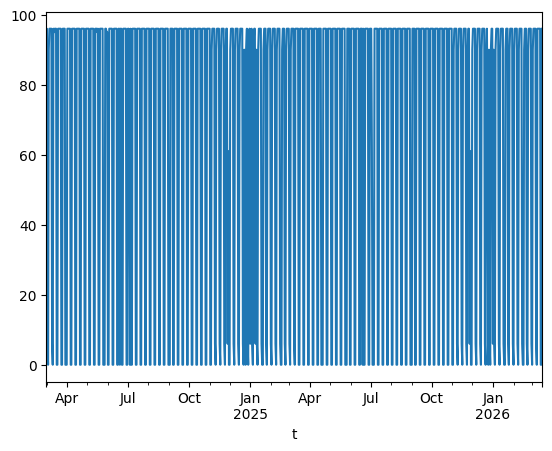

In [5]:
df.resample("1D").size().plot()

**Finding:** Weekdays consistently show ~95 candles. The small dips around
January 2025 correspond to NYSE holidays, not pipeline failures. Weekends
correctly appear as gaps in the index.

**Impact on features:** When building lags, the first Monday candle will
correctly point to the last Friday candle with no leakage risk.

## Identifying incomplete trading days

We filter out weekends and flag weekdays with fewer than 80 candles.
These are candidates for early market closes (e.g. day before Thanksgiving)
or collector failures that could introduce gaps in the lag features.

In [7]:
daily = df.resample("1D").size()
daily = daily[daily.index.dayofweek < 5]
daily[daily < 80].sort_values()

t
2024-03-29     0
2024-05-27     0
2024-06-19     0
2024-07-04     0
2024-09-02     0
2025-02-17     0
2025-04-18     0
2024-12-25     0
2025-05-26     0
2025-01-20     0
2026-01-19     0
2026-02-16     0
2025-12-25     0
2025-09-01     0
2025-07-04     0
2025-06-19     0
2025-01-01     6
2024-11-28     6
2025-11-27     6
2025-01-09     6
2026-01-01     6
2025-07-03    61
2024-07-03    61
2024-11-29    61
2025-11-28    61
2024-12-24    67
2025-12-24    67
dtype: int64

**Finding:** All flagged dates correspond to known NYSE holidays and early closes.
No collector failures detected on regular trading days.

- **Zero-candle days (0):** Federal holidays — Independence Day, Labor Day,
  MLK Day, Presidents Day, Good Friday, Juneteenth, Christmas, New Year's Day.
- **Half-sessions with ~6 candles:** Thanksgiving Day and New Year's Day 2025
  (market opened briefly).
- **Early closes with ~61-67 candles:** Day before Thanksgiving, Christmas Eve,
  and July 3rd — NYSE closes at 13:00 on these dates.

These dates will be flagged with a `is_short_session` boolean feature in
features.py, as price behavior during half-sessions differs from full days.

## Sentiment score distribution

We plot the distribution of the compound sentiment score (range [-1, 1])
to understand how news sentiment is spread across the dataset.
A score near -1 indicates strongly negative news, +1 strongly positive,
and 0 neutral or no news available.

<Axes: >

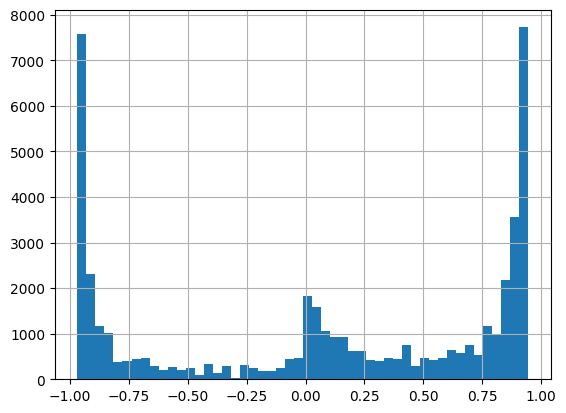

In [8]:
df["sentiment"].hist(bins=50)

**Finding:** The distribution is strongly bimodal with large spikes at -1 and +1,
and a smaller peak at 0. This suggests that most news articles carry a clear
strong sentiment rather than a neutral tone. The 0 spike corresponds to
timestamps with no news available (null-filled as 0).

**Impact on features:** Given the bimodal nature, the raw compound score may
already act as a near-binary signal. Consider adding a `sentiment_extreme`
boolean feature (abs(compound) > 0.8) in features.py to explicitly capture
this pattern, in addition to the raw score.

## News coverage frequency

We count the number of unique headlines to understand how often news
updates relative to the number of candles in the dataset.

In [9]:
df["headline"].nunique()

2639

**Finding:** Only 2,639 unique headlines across the full dataset, meaning
each news article covers multiple candles on average. The same headline
stays active for several 10-minute intervals until a new article is fetched.

**Impact on features:** The raw sentiment score will be highly autocorrelated
since it stays constant across consecutive candles. A rolling mean of sentiment
over the last 3-5 candles adds little new information in this case. Instead,
features.py should flag the **moment a headline changes** (`news_changed` boolean)
as that transition point is likely more informative than the score itself.

## Price return autocorrelation

We compute the lag-1 autocorrelation of 10-minute returns to check whether
past returns are predictive of future returns. A value near 0 indicates
no linear dependency, while a high value would suggest strong momentum.

In [10]:
df["c"].pct_change().autocorr(lag=1)

np.float64(0.006133113898206043)

**Finding:** Lag-1 autocorrelation is virtually zero (0.006), confirming that
raw returns have no meaningful linear dependency at the 10-minute level.
This is consistent with the efficient market hypothesis for liquid assets.

**Impact on features:** Lagged raw returns alone will not be useful features.
The model will need to rely on non-linear combinations of price features
(ATR, RSI, VWAP deviation) and sentiment signals to find predictive patterns.
This also reinforces why we start with a Ridge baseline — if it performs
poorly, it confirms the signal is non-linear and justifies moving to LightGBM.